##### Import Necessary Packages

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp

from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import wittgenstein as lw

##### Configuration

In [2]:
RESULTS_DIR = "../../temp_results/"
SAVE_DIR = "../../temp_results/grouped"

FOLDERS = ["AM", "AMt", "AM_p", "MOEAAM2", "MOEAAM2_DC", "MOEAAM2_IRS", 
           "MOEAAM2_IRS_DC", "MOEAAM2_SRS", "MOEAAM2_SRS_DC"] #, "MOEAAM2_SRS" , "MOEAAM2_SRS_DC", "AMt", "MOEAAMt", "MOEAAM_RSt", "MOEAAM_drop", "MOEAAM_RS_drop",

OBJECTIVES = ["spec_sens"]

DATASETS = [
    "mushrooms", "tictactoe", "hepatitis", "ljubljana", "cargood", "chess", "yeast3", "segment0", "pageblocks"
]

TARGET_METRICS = [
    "accuracy", "f1_score", "recall", "precision", "specificity", 
    "nb_rules", "term_rule_ratio", "hypervolume"
]

##### Results Aggregation

In [3]:
def process_results():
    dataset_results = {}

    for dataset in DATASETS:
        mean_rows = []
        std_rows = []
        
        for folder in FOLDERS:
            for obj in OBJECTIVES:
                file_path = os.path.join(RESULTS_DIR, folder, f"{dataset}_{obj}.csv")
                
                if not os.path.exists(file_path):
                    continue
                
                try:
                    df = pd.read_csv(file_path)
                    
                    # Normalization
                    if 'accuracy' in df.columns and df['accuracy'].dropna().max() <= 1.0001:
                        cols_to_scale = ["accuracy", "f1_score", "recall", "precision", "specificity"]
                        for col in cols_to_scale:
                            if col in df.columns:
                                df[col] = df[col] * 100
                    
                    # Mean and Std grouped by Split
                    numeric_cols = df.select_dtypes(include='number').columns
                    means_by_split = df.groupby('split')[numeric_cols].mean().round(3)
                    stds_by_split = df.groupby('split')[numeric_cols].std().round(3)
                    
                    
                    for split in ['train', 'test']:
                        if split in means_by_split.index:
                            
                            
                            base_info = {
                                "Algorithm": folder,
                                "Objective": obj,
                                "Split": split
                            }
                            
                            row_mean = base_info.copy()
                            row_std = base_info.copy()
                            
                            for metric in TARGET_METRICS:
                                if metric in means_by_split.columns:
                                    row_mean[metric] = means_by_split.loc[split, metric]
                                else:
                                    row_mean[metric] = None
                                
                                if metric in stds_by_split.columns:
                                    row_std[metric] = stds_by_split.loc[split, metric]
                                else:
                                    row_std[metric] = None
                            
                            mean_rows.append(row_mean)
                            std_rows.append(row_std)

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

        # Create DataFrames
        dataset_results[dataset] = {}
        
        if mean_rows:
            # Mean DataFrame
            df_mean = pd.DataFrame(mean_rows)
            df_mean.set_index(["Algorithm", "Objective", "Split"], inplace=True)
            dataset_results[dataset]['mean'] = df_mean
            
            # Std DataFrame
            df_std = pd.DataFrame(std_rows)
            df_std.set_index(["Algorithm", "Objective", "Split"], inplace=True)
            dataset_results[dataset]['std'] = df_std
        else:
            dataset_results[dataset]['mean'] = pd.DataFrame()
            dataset_results[dataset]['std'] = pd.DataFrame()

    return dataset_results

dfs = process_results()

In [4]:
for dataset, df in dfs.items():
    df['mean']['spec_sens'] = ( df['mean']['specificity'] * df['mean']['recall']) / 100
    df['mean']['spec_sens'] = df['mean']['spec_sens'].round(3)
    df['mean'].to_csv(os.path.join(SAVE_DIR, f"{dataset}_mean.csv"))
    df['std'].to_csv(os.path.join(SAVE_DIR, f"{dataset}_std.csv"))

##### Generalization 

In [5]:
sns.set_theme(style="whitegrid")

def plot_generalization_gap(results, datasets, metric="f1_score"):

    # Configuration
    colors = {'train': '#1f77b4', 'test': '#d62728', 'line': '#7f7f7f'}
    obj_map = {
        "spec_sens": "sp,se", "conf_simp": "conf,si", 
        "conf_spec": "conf,sp", "conf_sens": "conf,se"
    }
    
    fig, axes = plt.subplots(4, 3, figsize=(26, 20))
    axes_flat = axes.flatten()

    for i, ax in enumerate(axes_flat):
        if i >= len(datasets):
            ax.axis('off')
            continue
            
        ds_name = datasets[i]
        
        if ds_name not in results or 'mean' not in results[ds_name]:
            continue

        df = results[ds_name]['mean'].reset_index().copy()
        
        if metric not in df.columns:
            continue

        df['Label'] = df.apply(
            lambda x: f"{x['Algorithm']} ({obj_map.get(x['Objective'], x['Objective'])})", 
            axis=1
        )
        
        df_viz = df.pivot(index='Label', columns='Split', values=metric)
        if 'test' in df_viz.columns:
            df_viz = df_viz.sort_values(by='test', ascending=True)

        ax.hlines(y=df_viz.index, xmin=df_viz['test'], xmax=df_viz['train'], 
                  color=colors['line'], alpha=0.5, linewidth=3, zorder=1)
        
        ax.scatter(df_viz['train'], df_viz.index, color=colors['train'], s=80, zorder=2, label='Train' if i == 0 else "")
        ax.scatter(df_viz['test'], df_viz.index, color=colors['test'], s=80, zorder=2, label='Test' if i == 0 else "")

        for idx, label in enumerate(df_viz.index):
            train_val = df_viz.loc[label, 'train']
            test_val = df_viz.loc[label, 'test']
            
            ax.text(train_val, idx + 0.15, f"{train_val:.1f}", 
                    ha='center', va='bottom', fontsize=9, color=colors['train'], fontweight='bold')

            is_close = abs(train_val - test_val) < 2.0
            test_va = 'top' if is_close else 'bottom'
            test_offset = -0.15 if is_close else 0.15

            ax.text(test_val, idx + test_offset, f"{test_val:.1f}", 
                    ha='center', va=test_va, fontsize=9, color=colors['test'], fontweight='bold')

        ax.set_title(ds_name.capitalize(), fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xlim(0, 103)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.99))

    fig.suptitle(f"Generalization Gap ({metric.replace('_', ' ').capitalize()})", fontsize=18, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [6]:
#plot_generalization_gap(dfs, DATASETS, metric="accuracy")

In [7]:
#plot_generalization_gap(dfs, DATASETS, metric="f1_score")

In [8]:
#plot_generalization_gap(dfs, DATASETS, metric="recall")

In [9]:
#plot_generalization_gap(dfs, DATASETS, metric="precision")

In [10]:
#plot_generalization_gap(dfs, DATASETS, metric="specificity")

##### Results Ranking

In [99]:
def get_ranking_df(df_values):

    df_ranks = df_values.rank(axis=1, ascending=False, method='average')
    avg_ranks = df_ranks.mean(axis=0)
    df_ranks.loc['Average Rank'] = avg_ranks
    df_ranks= df_ranks.map(lambda x: f'{x:g}')
    
    return df_ranks

def get_ranking(df_values, ascending=False):
    ranks = df_values.rank(axis=1, ascending=ascending, method='average')
    df_out = df_values.map('{:g}'.format) + " (" + ranks.map('{:g}'.format) + ")"
    df_out.loc['Average Rank'] = ranks.mean().map('{:.4g}'.format)

    return df_out, ranks.mean()

LABEL_MAP = {
    "AM(spec_sens)": r"$\mathrm{AntMiner}$",
    "MOEAAM2(spec_sens)": r"$MOAM_{p}^{*}$",
    "MOEAAM2_DC(spec_sens)": r"$MOAM_{p}$",
    "MOEAAM2_IRS(spec_sens)": r"$MOAM_{m}^{*}$",
    "MOEAAM2_IRS_DC(spec_sens)": r"$MOAM_{m}$"
}

def plot_avg_ranks(avg_ranks, metric_name):
    sorted_avg_ranks = avg_ranks.sort_values()

    # colors BEFORE renaming
    colors = [
        'tab:red' if name == 'AM(spec_sens)' else 'lightgrey'
        for name in sorted_avg_ranks.index
    ]

    # now rename for plotting
    sorted_avg_ranks = sorted_avg_ranks.rename(index=LABEL_MAP)

    plt.figure(figsize=(12, 6))
    sorted_avg_ranks.plot(kind='barh', color=colors)

    plt.xlabel('Mean Rank')
    plt.axvline(x=sorted_avg_ranks.mean(), linestyle='--', label='Global Average')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [100]:
def extract_means(results_data, folders, target_metric="accuracy"):
    friedman_dict = {}

    for folder in folders:
        for obj in OBJECTIVES:
            
            dict_key = f"{folder}({obj})"    
            scores_list = []
            
            for dataset in DATASETS:
                if dataset not in results_data or 'mean' not in results_data[dataset]:
                    scores_list.append(None)
                    continue
                
                df_mean = results_data[dataset]['mean']
                
                if df_mean.empty:
                    scores_list.append(None)
                    continue
                
                try:
                    val = df_mean.loc[(folder, obj, 'test'), target_metric]
                    scores_list.append(round(val, 2))
                    
                except KeyError:
                    scores_list.append(None)
            
            friedman_dict[dict_key] = scores_list

    return friedman_dict

In [101]:
folders = ["AM", "MOEAAM2", "MOEAAM2_DC", "MOEAAM2_IRS", "MOEAAM2_IRS_DC"]

1. ACCURACY

In [102]:
accuracy_dict = extract_means(dfs, folders=folders, target_metric="accuracy")

accuracy_df = pd.DataFrame(accuracy_dict, index=DATASETS)
accuracy_ranks, accuracy_avg_ranks = get_ranking(accuracy_df)
accuracy_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,91.03 (1),70.3 (5),89.47 (2),72.22 (4),81.86 (3)
tictactoe,72.82 (1),43.97 (5),66.49 (3),63.13 (4),71.4 (2)
hepatitis,75.1 (4),82.84 (2),82.71 (3),83.74 (1),51.1 (5)
ljubljana,72.64 (1),67.13 (4),68.23 (2),67.64 (3),50.21 (5)
cargood,95.66 (1),95.44 (3),95.52 (2),95.18 (4),95.14 (5)
chess,96.53 (2),95.76 (3),96.79 (1),95.6 (4),85.43 (5)
yeast3,88.33 (4),89.92 (2.5),90.01 (1),89.92 (2.5),77.7 (5)
segment0,93.06 (4),94.16 (3),94.52 (2),95.6 (1),76.29 (5)
pageblocks,83.2 (1),79.17 (4),79.61 (2),79.43 (3),74.91 (5)
Average Rank,2.111,3.5,2,2.944,4.444


In [103]:
#plot_avg_ranks(accuracy_avg_ranks, "Accuracy")

2. F1-SCORE

In [104]:
f1_dict = extract_means(dfs, folders=folders, target_metric="f1_score")

f1_df = pd.DataFrame(f1_dict, index=DATASETS)
f1_ranks, f1_avg_ranks = get_ranking(f1_df)
f1_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,90.15 (1),75.91 (5),88.42 (2),77.72 (4),85.89 (3)
tictactoe,80.46 (2),27.23 (5),72.98 (3),69.47 (4),81.48 (1)
hepatitis,37.45 (5),49.93 (2),46.16 (3),53.56 (1),44.3 (4)
ljubljana,42.39 (4),43.05 (1),36.64 (5),42.68 (2),42.61 (3)
cargood,53.03 (1),7.88 (5),11.5 (4),20.42 (2),18.47 (3)
chess,58.98 (1),55.71 (3),49.98 (4),56.68 (2),40.78 (5)
yeast3,23.41 (5),43.38 (3),43.41 (2),44.55 (1),38.09 (4)
segment0,77 (4),77.75 (3),79.29 (2),86.19 (1),66.22 (5)
pageblocks,40.85 (1),3.9 (5),7.12 (3),5.37 (4),7.81 (2)
Average Rank,2.667,3.556,3.111,2.333,3.333


In [105]:
#plot_avg_ranks(f1_avg_ranks, "F1 Score")

3. RECALL

In [106]:
recall_dict = extract_means(dfs, folders=folders, target_metric="recall")

recall_df = pd.DataFrame(recall_dict, index=DATASETS)
recall_ranks, recall_avg_ranks = get_ranking(recall_df)


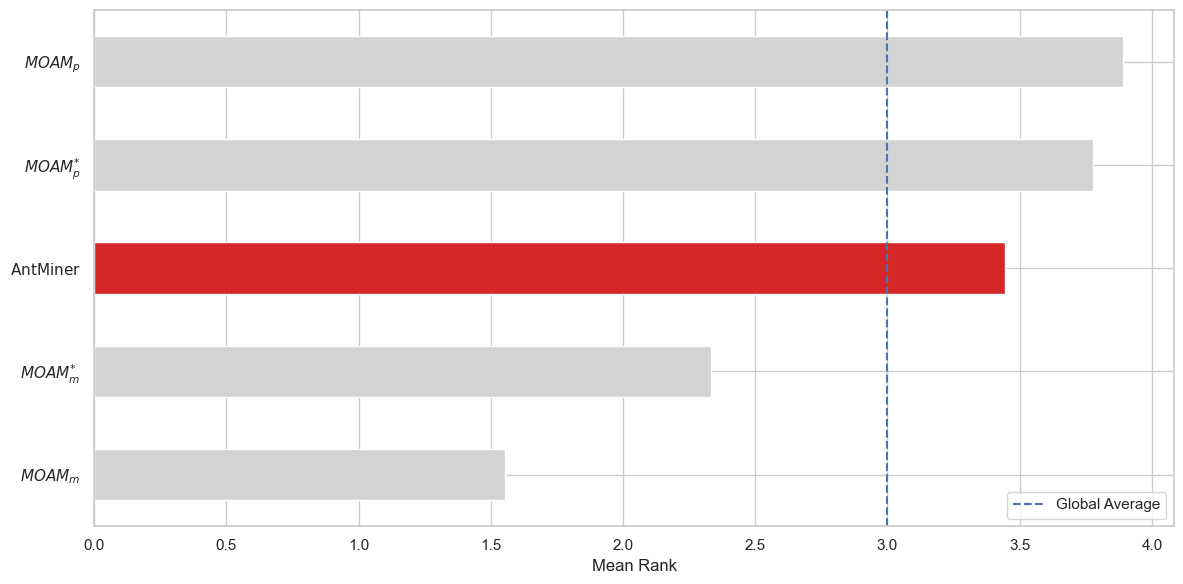

In [107]:
plot_avg_ranks(recall_avg_ranks, "Recall")

4. PRECISION

In [108]:
precision_dict = extract_means(dfs, folders=folders, target_metric="precision")

precision_df = pd.DataFrame(precision_dict, index=DATASETS)
precision_ranks, precision_avg_ranks = get_ranking(precision_df)
precision_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,97.4 (1),62.59 (5),91.47 (2),63.88 (4),77.96 (3)
tictactoe,75.64 (3),91.07 (1),76.07 (2),75.48 (4),70.78 (5)
hepatitis,41.35 (4),61.87 (3),65.07 (2),67.67 (1),40.14 (5)
ljubljana,59.48 (1),42.62 (2),38.45 (4),42.09 (3),38.38 (5)
cargood,47.39 (1),17.41 (5),32.33 (2),28.5 (4),29.8 (3)
chess,52.28 (2),49.31 (3),61.86 (1),46.79 (4),34.49 (5)
yeast3,36.92 (5),60.41 (1),60.17 (2),59.3 (3),41.56 (4)
segment0,74.74 (4),85.92 (2),86.05 (1),80.83 (3),60.71 (5)
pageblocks,70.45 (1),15.83 (4),45.16 (2),28.14 (3),15.5 (5)
Average Rank,2.444,2.889,2,3.222,4.444


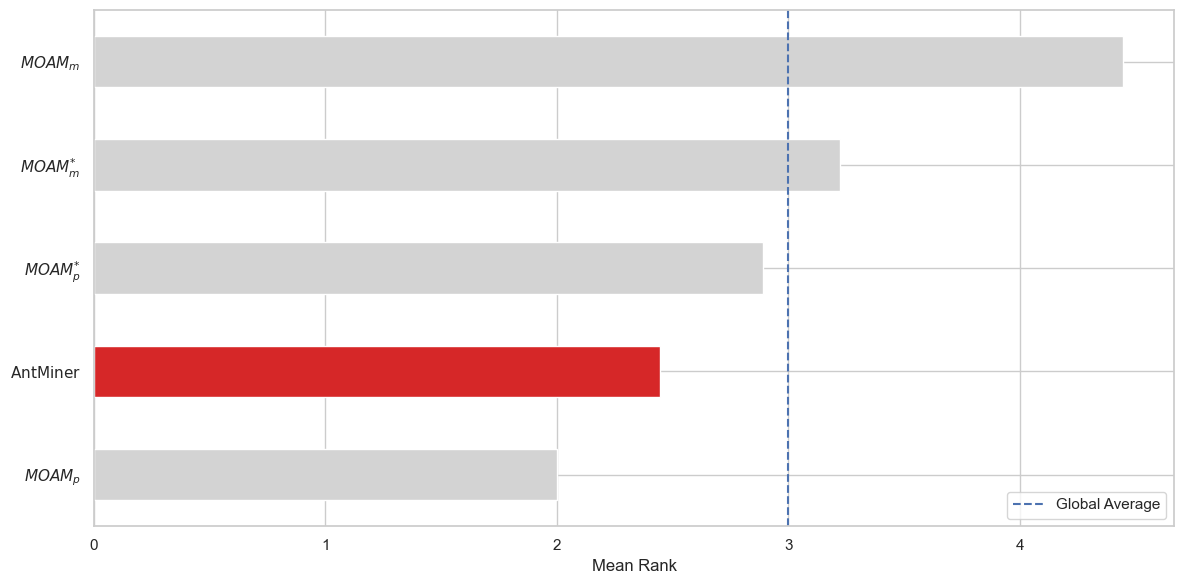

In [109]:
plot_avg_ranks(precision_avg_ranks, "Precision")

5. SPECIFICITY

In [110]:
specificity_dict = extract_means(dfs, folders=folders, target_metric="specificity")

specificity_df = pd.DataFrame(specificity_dict, index=DATASETS)
specificity_ranks, specificity_avg_ranks = get_ranking(specificity_df)
specificity_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,97.32 (1),45.65 (5),91.86 (2),46.71 (4),66.19 (3)
tictactoe,47.55 (4),95.29 (1),57.22 (3),58.34 (2),24.61 (5)
hepatitis,85.02 (4),93.19 (3),94.31 (1),93.48 (2),43.98 (5)
ljubljana,88.66 (1),75.95 (4),81.9 (2),77.26 (3),43.76 (5)
cargood,97 (5),99.19 (1),99.17 (2),98.42 (3.5),98.42 (3.5)
chess,97.55 (2),96.73 (3),98.64 (1),96.34 (4),85.73 (5)
yeast3,97.26 (1),96.88 (3),97.04 (2),96.72 (4),81.11 (5)
segment0,94.98 (4),98.02 (1),97.98 (2),95.95 (3),73.72 (5)
pageblocks,97.13 (4),99.44 (3),99.62 (2),99.65 (1),91.74 (5)
Average Rank,2.889,2.667,1.889,2.944,4.611


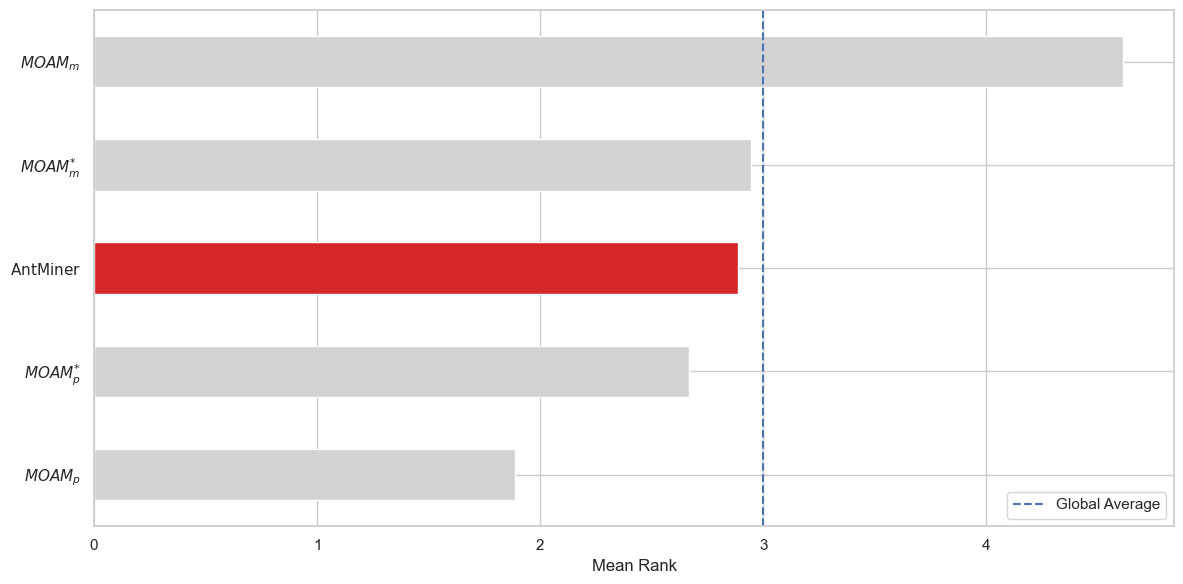

In [111]:
plot_avg_ranks(specificity_avg_ranks, "Specificity")

In [112]:
spec_sens_dict = extract_means(dfs, folders=folders, target_metric="spec_sens")

spec_sens_df = pd.DataFrame(spec_sens_dict, index=DATASETS)
spec_sens_ranks, spec_sens_avg_ranks = get_ranking(spec_sens_df)
spec_sens_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,82.02 (1),44.18 (5),79.83 (2),46.54 (4),65.33 (3)
tictactoe,41 (1),15.96 (5),40.85 (2),38.33 (3),23.68 (4)
hepatitis,31.42 (5),40.21 (2),36.11 (3),43.18 (1),33.89 (4)
ljubljana,30.78 (3),35.38 (1),29.58 (4),34.75 (2),28.47 (5)
cargood,61.5 (1),5.17 (5),7.74 (4),17.07 (2),15.81 (3)
chess,67.64 (2),67.62 (3),46.78 (5),73.04 (1),66.46 (4)
yeast3,17.82 (5),34.22 (3),33.87 (4),35.36 (2),41.33 (1)
segment0,77.47 (2),69.78 (4),72.39 (3),89.77 (1),67.58 (5)
pageblocks,29.72 (1),2.58 (5),4.03 (3),3.04 (4),10.47 (2)
Average Rank,2.333,3.667,3.333,2.222,3.444


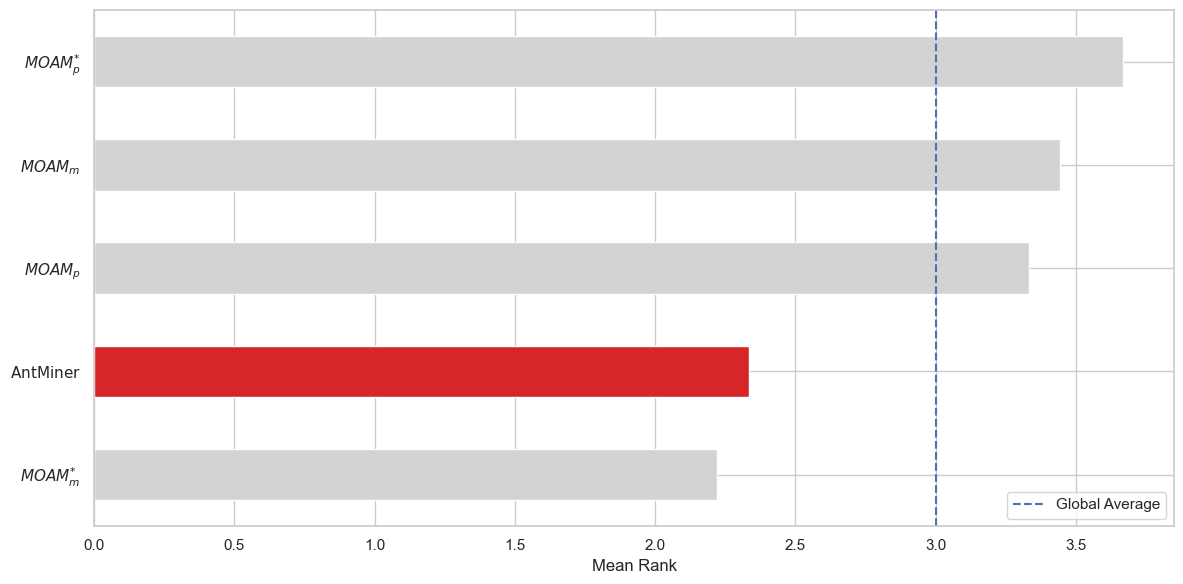

In [113]:
plot_avg_ranks(spec_sens_avg_ranks, "Spec_Sens")

In [114]:
nb_rules_dict = extract_means(dfs, folders=folders, target_metric="nb_rules")

nb_rules_df = pd.DataFrame(nb_rules_dict, index=DATASETS)
nb_rules_ranks, nb_rules_avg_ranks = get_ranking(nb_rules_df, ascending=True)
nb_rules_ranks

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,7.88 (4),5.36 (3),3.48 (1),97.6 (5),4.88 (2)
tictactoe,18.48 (5),2.6 (1),9.16 (2),18.32 (4),14.2 (3)
hepatitis,5 (4),1.72 (2),1.08 (1),12.56 (5),2.84 (3)
ljubljana,6.64 (4),1.4 (2),0.88 (1),7 (5),2.52 (3)
cargood,15.12 (5),2.32 (2),1.76 (1),10.56 (4),4.12 (3)
chess,15.84 (5),4.64 (2),2 (1),11.12 (4),5.08 (3)
yeast3,16.32 (5),1.64 (2),1.32 (1),14.96 (4),2.44 (3)
segment0,15.12 (4),2.84 (2),2.28 (1),70 (5),6.56 (3)
pageblocks,8.44 (5),0.36 (1),0.8 (4),0.48 (2),0.72 (3)
Average Rank,4.556,1.889,1.444,4.222,2.889


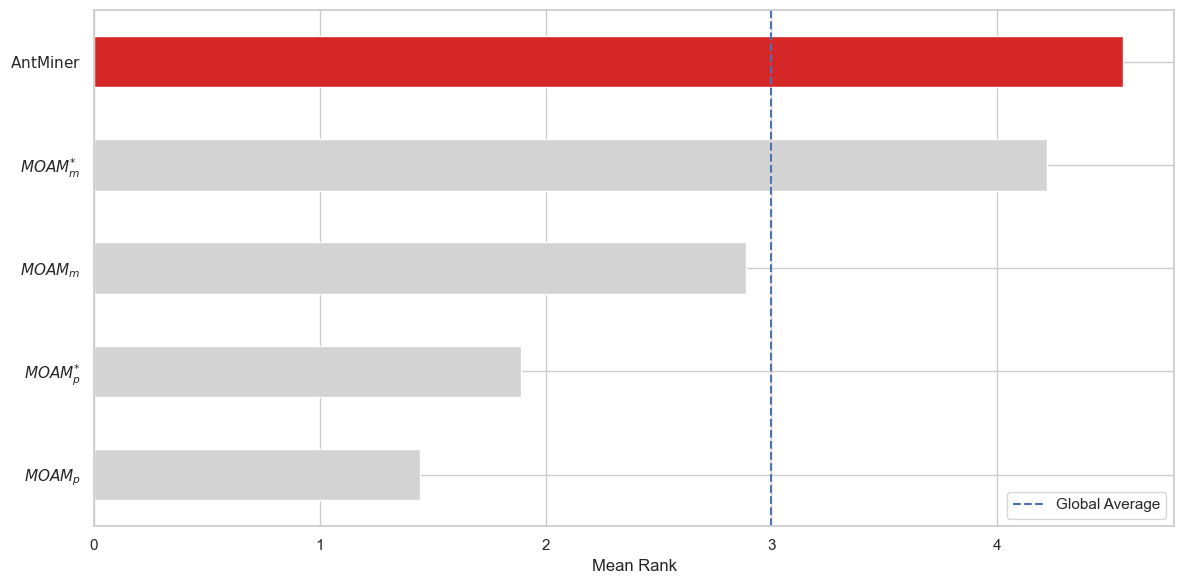

In [115]:
plot_avg_ranks(nb_rules_avg_ranks, "the Number of Rules")

##### Friedman Tests

In [28]:
data = {
    "Accuracy": accuracy_dict,
    "F1 Score": f1_df,
    "Recall": recall_df,
    "Precision": precision_df,
    "Specificity": specificity_df,
    "Spec Sens": spec_sens_df,
    "nb_rules": nb_rules_df
}

In [29]:
def friedman_test(data):
    results = []
    
    for metric, data in data.items():
        df = pd.DataFrame(data, index=DATASETS)
        
        stat, p_value = friedmanchisquare(*[df[col] for col in df.columns])
        
        results.append({
            "Metric": metric,
            "Chi-square Stat": stat,
            "P-value": p_value
        })
    
    return pd.DataFrame(results)

friedman_results = friedman_test(data)
friedman_results

,Metric,Chi-square Stat,P-value
0,Accuracy,14.949721,0.004807
1,F1 Score,3.555556,0.469481
2,Recall,14.844444,0.005035
3,Precision,12.444444,0.014335
4,Specificity,14.324022,0.006330
5,Spec Sens,6.488889,0.165492
6,nb_rules,27.288889,0.000017


##### Wilcoxon Posthoc

In [30]:
LABEL_MAP = {
    "AM(spec_sens)": r"$\mathrm{AntMiner}$",
    "MOEAAM2(spec_sens)": r"$MOAM_{p}^{*}$",
    "MOEAAM2_DC(spec_sens)": r"$MOAM_{p}$",
    "MOEAAM2_IRS(spec_sens)": r"$MOAM_{m}^{*}$",
    "MOEAAM2_IRS_DC(spec_sens)": r"$MOAM_{m}$"
}


In [31]:
def get_avg_ranks(df, higher_is_better=True):
    return df.rank(axis=1, ascending=not higher_is_better, method='average').mean()

def compute_p_values(df, apply_correction=1):
    algos = df.columns
    n = len(algos)
    pairs = []
    p_values_raw = []

    for i in range(n):
        for j in range(i + 1, n):
            stat, p = wilcoxon(df[algos[i]], df[algos[j]], zero_method='zsplit')
            pairs.append((i, j))
            p_values_raw.append(p)

    if apply_correction == 1:
        _, p_final, _, _ = multipletests(p_values_raw, method='holm')
    else:
        p_final = p_values_raw

    return pairs, p_final

def wilcoxon_posthoc(df, apply_correction=1, p_threshold=0.05, metric_name=None, higher_is_better=True):
    
    # 🔹 rename columns for plotting (LaTeX labels)
    df = df.rename(columns=LABEL_MAP)

    algos = df.columns
    
    pairs, p_final = compute_p_values(df, apply_correction)
    
    p_matrix = pd.DataFrame(index=algos, columns=algos, dtype=float)
    np.fill_diagonal(p_matrix.values, 1.0)
    
    print(f"{'='*10} Significant Pairs (Correction={bool(apply_correction)}) {'='*10}")
    
    for (i, j), p_val in zip(pairs, p_final):
        p_matrix.iloc[i, j] = p_val
        p_matrix.iloc[j, i] = p_val
        
        if p_val < p_threshold:
            print(f"{algos[i]} vs {algos[j]}: p={p_val:.5f}")

    ranks = get_avg_ranks(df, higher_is_better)

    plt.figure(figsize=(10, 3))
    sp.critical_difference_diagram(ranks=ranks, sig_matrix=p_matrix)
    #plt.title(f"Critical Difference Diagram for {metric_name}")
    plt.show()

    return p_matrix


========== Significant Pairs (Correction=True) ==========
$\mathrm{AntMiner}$ vs $MOAM_{p}^{*}$: p=0.03906
$\mathrm{AntMiner}$ vs $MOAM_{p}$: p=0.03906
$\mathrm{AntMiner}$ vs $MOAM_{m}$: p=0.03906
$MOAM_{p}^{*}$ vs $MOAM_{m}^{*}$: p=0.03906
$MOAM_{p}$ vs $MOAM_{m}^{*}$: p=0.04688
$MOAM_{p}$ vs $MOAM_{m}$: p=0.04688
$MOAM_{m}^{*}$ vs $MOAM_{m}$: p=0.04688


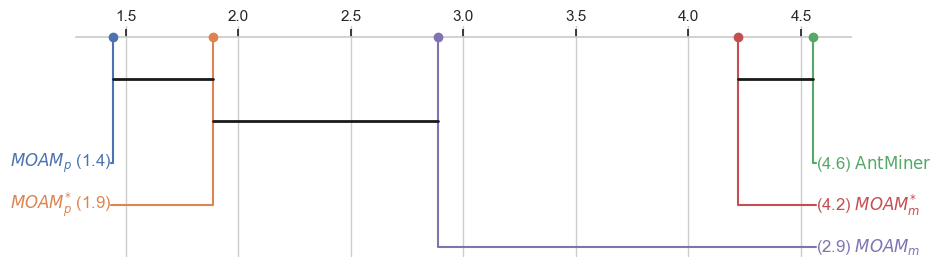

,$\mathrm{AntMiner}$,$MOAM_{p}^{*}$,$MOAM_{p}$,$MOAM_{m}^{*}$,$MOAM_{m}$
$\mathrm{AntMiner}$,1.000000,0.039062,0.039062,0.820312,0.039062
$MOAM_{p}^{*}$,0.039062,1.000000,0.406250,0.039062,0.058594
$MOAM_{p}$,0.039062,0.406250,1.000000,0.046875,0.046875
$MOAM_{m}^{*}$,0.820312,0.039062,0.046875,1.000000,0.046875
$MOAM_{m}$,0.039062,0.058594,0.046875,0.046875,1.000000


In [33]:
p_matrix = wilcoxon_posthoc(nb_rules_df, higher_is_better=False, apply_correction=1, metric_name="Specificity")
p_matrix

========== Significant Pairs (Correction=True) ==========
$MOAM_{p}^{*}$ vs $MOAM_{m}$: p=0.03906
$MOAM_{p}$ vs $MOAM_{m}$: p=0.03906


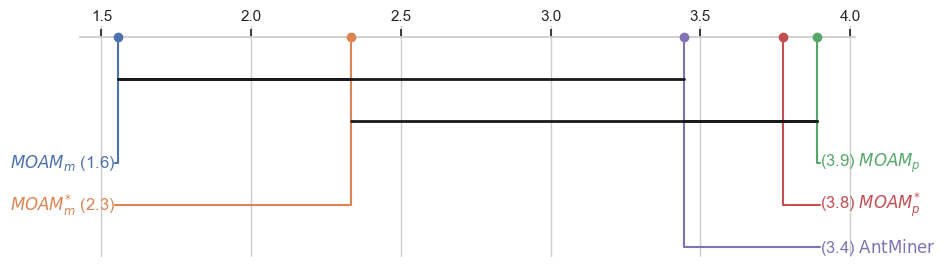

,$\mathrm{AntMiner}$,$MOAM_{p}^{*}$,$MOAM_{p}$,$MOAM_{m}^{*}$,$MOAM_{m}$
$\mathrm{AntMiner}$,1.0,1.000000,1.000000,1.000000,1.000000
$MOAM_{p}^{*}$,1.0,1.000000,1.000000,0.156250,0.039062
$MOAM_{p}$,1.0,1.000000,1.000000,0.191406,0.039062
$MOAM_{m}^{*}$,1.0,0.156250,0.191406,1.000000,0.445312
$MOAM_{m}$,1.0,0.039062,0.039062,0.445312,1.000000


In [105]:
p_matrix = wilcoxon_posthoc(recall_df, apply_correction=1, metric_name="Sensitivity")
p_matrix

========== Significant Pairs (Correction=True) ==========


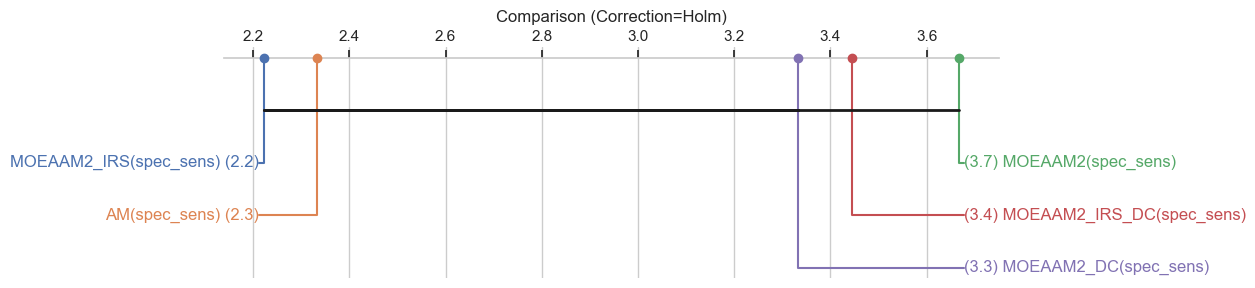

,AM(spec_sens),MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens),MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
AM(spec_sens),1.0,1.000000,1.0,1.000000,1.0
MOEAAM2(spec_sens),1.0,1.000000,1.0,0.117188,1.0
MOEAAM2_DC(spec_sens),1.0,1.000000,1.0,1.000000,1.0
MOEAAM2_IRS(spec_sens),1.0,0.117188,1.0,1.000000,1.0
MOEAAM2_IRS_DC(spec_sens),1.0,1.000000,1.0,1.000000,1.0


In [74]:
p_matrix = wilcoxon_posthoc(spec_sens_df, apply_correction=1)
p_matrix

##### Specific Friedman Tests

In [556]:
new_folders = ["AM", "AMt"]

custom_dict = extract_means(dfs, folders=new_folders, target_metric="nb_rules", )

custom_df = pd.DataFrame(custom_dict, index=DATASETS)
custom_ranks, custom_avg_ranks = get_ranking(custom_df, ascending=True)
custom_ranks

,AM(spec_sens),AMt(spec_sens)
mushrooms,7.88 (1),12.94 (2)
tictactoe,18.48 (1),34.88 (2)
hepatitis,5 (1),344.1 (2)
ljubljana,6.64 (1),40.12 (2)
cargood,15.12 (2),11.76 (1)
chess,15.84 (1),16.26 (2)
zoo3,2.84 (1),10.28 (2)
flare,8.4 (1),13.1 (2)
yeast3,16.32 (1),102.22 (2)
segment0,15.12 (1),45 (2)


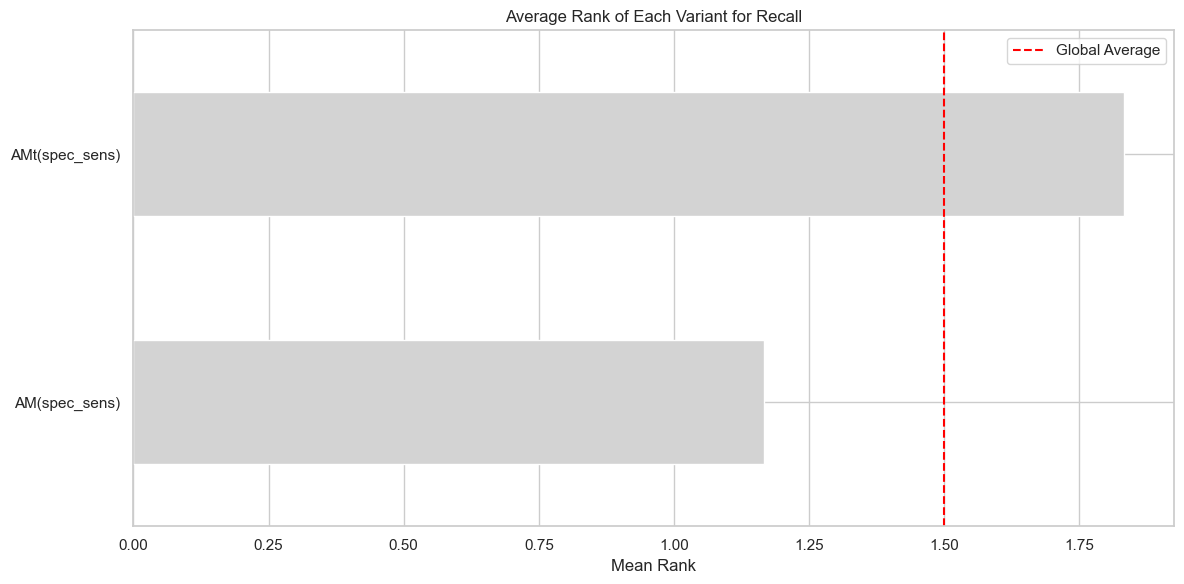

In [557]:
plot_avg_ranks(custom_avg_ranks, "Recall")

========== Significant Pairs (Correction=True) ==========


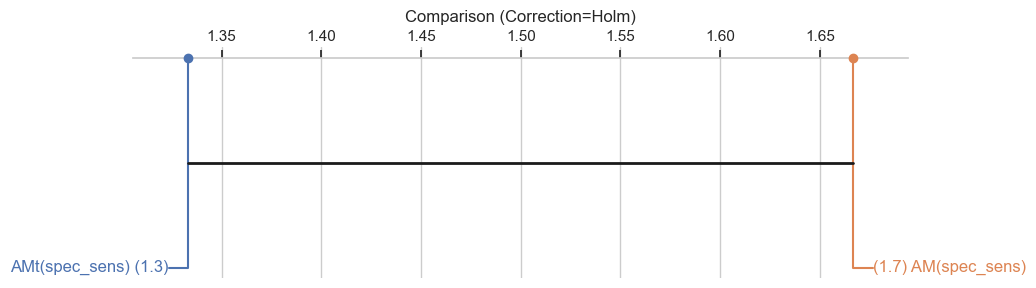

,AM(spec_sens),AMt(spec_sens)
AM(spec_sens),1.000,0.077
AMt(spec_sens),0.077,1.000


In [510]:
p_matrix = wilcoxon_posthoc(custom_df)
p_matrix = p_matrix.map(lambda x: f"{x:.3f}")
p_matrix

In [511]:
new_folders = ["MOEAAM2", "MOEAAM2_DC"]

custom_dict = extract_means(dfs, folders=new_folders, target_metric="specificity")

custom_df = pd.DataFrame(custom_dict, index=DATASETS)
custom_ranks, custom_avg_ranks = get_ranking(custom_df)
custom_ranks

,MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens)
mushrooms,45.65 (2),91.86 (1)
tictactoe,95.29 (1),57.22 (2)
hepatitis,93.19 (2),94.31 (1)
ljubljana,75.95 (2),81.9 (1)
cargood,99.19 (1),99.17 (2)
chess,96.73 (2),98.64 (1)
zoo3,100 (1.5),100 (1.5)
flare,100 (1.5),100 (1.5)
yeast3,96.88 (2),97.04 (1)
segment0,98.02 (1),97.98 (2)


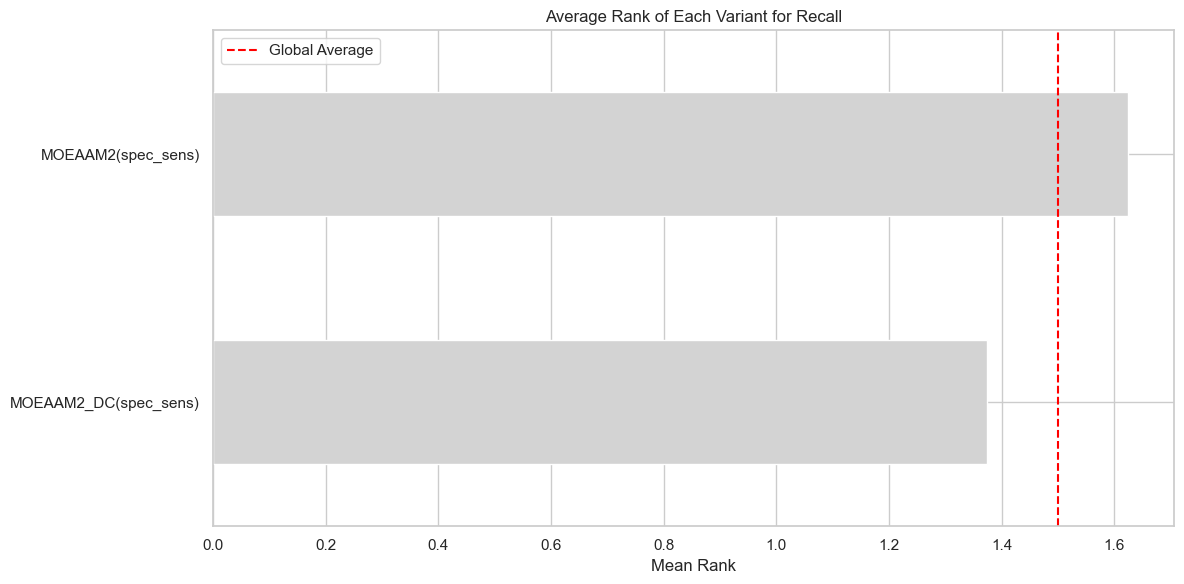

In [512]:
plot_avg_ranks(custom_avg_ranks, "Recall")

========== Significant Pairs (Correction=True) ==========


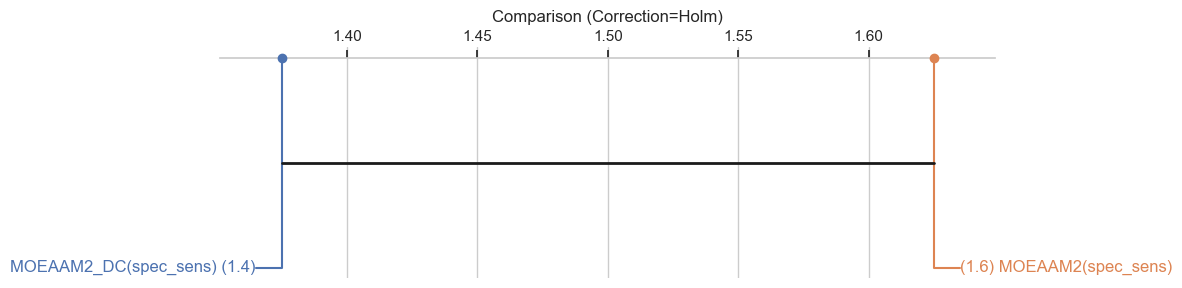

,MOEAAM2(spec_sens),MOEAAM2_DC(spec_sens)
MOEAAM2(spec_sens),1.000,0.227
MOEAAM2_DC(spec_sens),0.227,1.000


In [513]:
p_matrix = wilcoxon_posthoc(custom_df)
p_matrix = p_matrix.map(lambda x: f"{x:.3f}")
p_matrix

In [514]:
new_folders = ["MOEAAM2_IRS", "MOEAAM2_IRS_DC"]

custom_dict = extract_means(dfs, folders=new_folders, target_metric="specificity")

custom_df = pd.DataFrame(custom_dict, index=DATASETS)
custom_ranks, custom_avg_ranks = get_ranking(custom_df)
custom_ranks

,MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
mushrooms,46.71 (2),66.19 (1)
tictactoe,58.34 (1),24.61 (2)
hepatitis,93.48 (1),43.98 (2)
ljubljana,77.26 (1),43.76 (2)
cargood,98.42 (1.5),98.42 (1.5)
chess,96.34 (1),85.73 (2)
zoo3,100 (1.5),100 (1.5)
flare,100 (1.5),100 (1.5)
yeast3,96.72 (1),81.11 (2)
segment0,95.95 (1),73.72 (2)


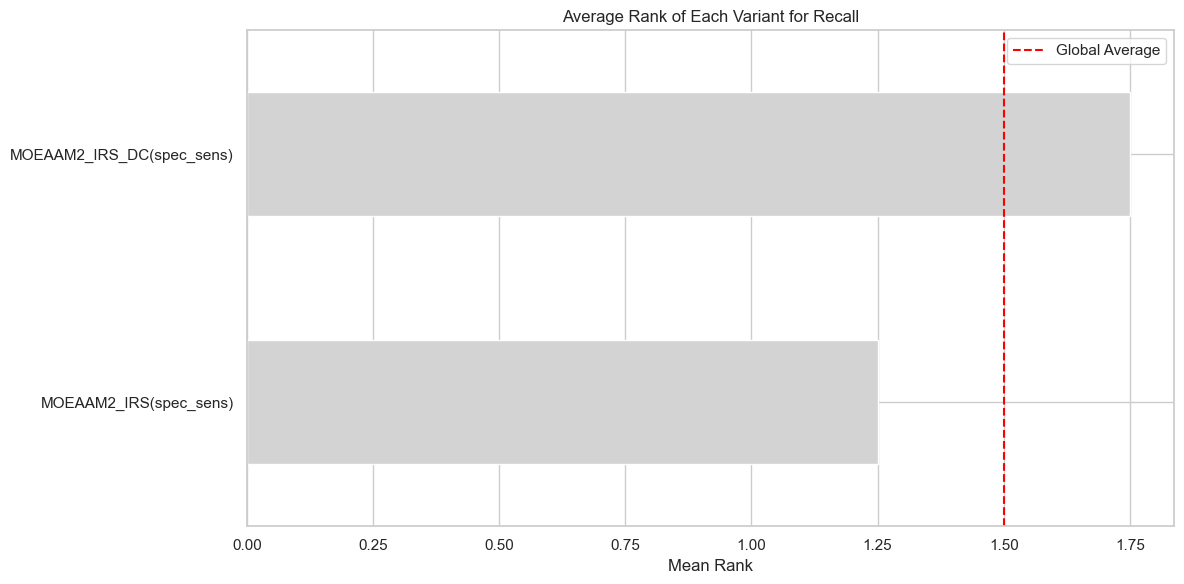

In [515]:
plot_avg_ranks(custom_avg_ranks, "Recall")

========== Significant Pairs (Correction=True) ==========
MOEAAM2_IRS(spec_sens) vs MOEAAM2_IRS_DC(spec_sens): p=0.03906


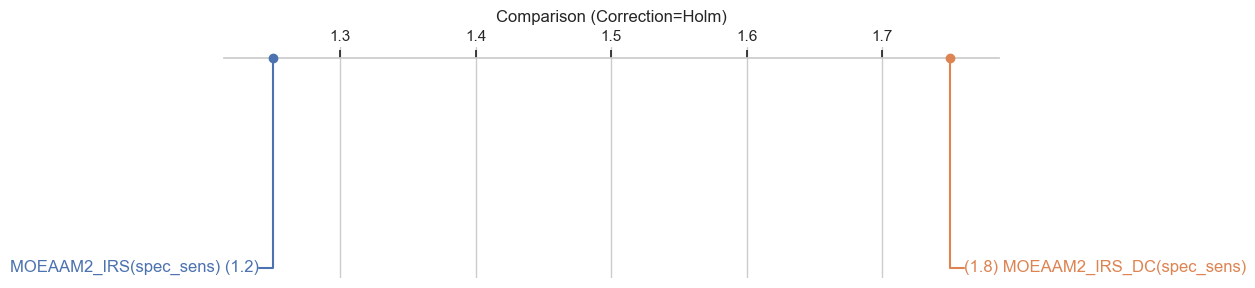

,MOEAAM2_IRS(spec_sens),MOEAAM2_IRS_DC(spec_sens)
MOEAAM2_IRS(spec_sens),1.000,0.039
MOEAAM2_IRS_DC(spec_sens),0.039,1.000


In [516]:
p_matrix = wilcoxon_posthoc(custom_df)
p_matrix = p_matrix.map(lambda x: f"{x:.3f}")
p_matrix

##### Classical Classification Algorithms

In [302]:
DATASETS_PATH = "../../datasets/SLC/"
def calculate_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
    prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred)
    
    if cm.shape == (2, 2):

        tn, fp, _, _ = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc * 100,
        "f1_score": f1 * 100,
        "recall": rec * 100,
        "precision": prec * 100,
        "specificity": spec * 100
    }

In [303]:
def get_baseline_results(datasets):
    baseline_data = []
    
    print(f"Running Training (RIPPER, C4.5, CS-C4.5)...")
    print("-" * 60)

    for ds in datasets:
        path = os.path.join(DATASETS_PATH, f"{ds}.csv")
        if not os.path.exists(path):
            path = path.replace(".csv", ".data")
        
        if not os.path.exists(path):
            continue

        try:
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip()
            if 'class' not in df.columns: continue
            
            y = LabelEncoder().fit_transform(df['class'])
            X = pd.get_dummies(df.drop('class', axis=1)).values
        except:
            continue

        n_folds = min(5, len(y))
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        
        algos = ["C4.5", "CS-C4.5", "RIPPER"]
        fold_results = {algo: {m: [] for m in ["accuracy", "f1_score", "recall", "precision", "specificity"]} for algo in algos}
        
        models = {
            "C4.5": DecisionTreeClassifier(criterion='entropy', random_state=42),
            "CS-C4.5": DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42),
            "RIPPER": lw.RIPPER(random_state=42)
        }

        print(f"Running {ds}...")

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            for name, model in models.items():
                try:
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    
                    metrics = calculate_metrics(y_test, y_pred)
                    
                    for m_name, m_val in metrics.items():
                        fold_results[name][m_name].append(m_val)
                except:
                    pass

        for name in algos:
            row = {"Dataset": ds, "Algorithm": name}
            for m in ["accuracy", "f1_score", "recall", "precision", "specificity"]:
                vals = fold_results[name][m]
                row[m] = np.mean(vals) if vals else 0.0
            
            baseline_data.append(row)

    return pd.DataFrame(baseline_data)

In [304]:
df_baselines = get_baseline_results(DATASETS)

Running Training (RIPPER, C4.5, CS-C4.5)...
------------------------------------------------------------
Running mushrooms...
Running tictactoe...
Running hepatitis...
Running ljubljana...
Running cargood...
Running chess...
Running zoo3...
Running flare...
Running yeast3...
Running segment0...
Running abalone19...
Running pageblocks...


In [305]:
df_baselines
#df_baselines.to_csv(os.path.join(SAVE_DIR, "baseline_results.csv"), index=False)

,Dataset,Algorithm,accuracy,f1_score,recall,precision,specificity
0,mushrooms,C4.5,100.000000,100.000000,100.000000,100.000000,100.000000
1,mushrooms,CS-C4.5,100.000000,100.000000,100.000000,100.000000,100.000000
2,mushrooms,RIPPER,100.000000,100.000000,100.000000,100.000000,100.000000
3,tictactoe,C4.5,93.636562,95.148319,95.372698,94.954080,90.370873
4,tictactoe,CS-C4.5,93.530214,95.011918,94.252698,95.797262,92.170963
5,tictactoe,RIPPER,98.954516,99.210069,99.682540,98.755809,97.575758
6,hepatitis,C4.5,72.903226,44.537815,53.809524,39.148629,78.066667
7,hepatitis,CS-C4.5,77.419355,45.807526,48.095238,44.825397,85.300000
8,hepatitis,RIPPER,80.645161,50.434343,44.285714,60.777778,90.100000
9,ljubljana,C4.5,64.680135,40.765300,41.838235,40.194828,74.345479


In [306]:
def compare_best(baseline_df, user_results_dict, datasets, metric="f1_score"):
    comparison_rows = []
    
    print(f"\n{'Dataset':<15} | {'Best Algo':<25} | {metric + ' %':<6}")
    print("-" * 80)
    
    for ds in datasets:

        ds_base = baseline_df[baseline_df['Dataset'] == ds]
        
        if not ds_base.empty:
            best_base_row = ds_base.loc[ds_base[metric].idxmax()]
            best_base_name = best_base_row['Algorithm']
            best_base_f1 = best_base_row[metric]
            best_base_acc = best_base_row['accuracy']
        else:
            best_base_name, best_base_f1, best_base_acc = "None", 0, 0

        best_user_name = "None"
        best_user_f1 = 0
        best_user_acc = 0
        
        if ds in user_results_dict and 'mean' in user_results_dict[ds]:
            df_user = user_results_dict[ds]['mean']
            if not df_user.empty:
                try:
                    test_df = df_user.xs('test', level='Split')
                    
                    if metric in test_df.columns:
                        idx_best = test_df[metric].idxmax()
                        
                        best_user_f1 = test_df.loc[idx_best, metric]
                        best_user_acc = test_df.loc[idx_best, 'accuracy']
                        best_user_name = f"{idx_best[0]} ({idx_best[1]})"
                except:
                    pass

        if best_user_f1 >= best_base_f1:
            winner = best_user_name
            win_f1 = best_user_f1
        else:
            winner = best_base_name
            win_f1 = best_base_f1
            
        print(f"{ds:<15} | {winner:<25} | {win_f1:.2f}")
        
        comparison_rows.append({
            "Dataset": ds,
            "Best_Algo": winner,
            metric: win_f1,
        })

    return pd.DataFrame(comparison_rows)

In [309]:
leaderboard = compare_best(df_baselines, dfs, DATASETS, metric="specificity")


Dataset         | Best Algo                 | specificity %
--------------------------------------------------------------------------------
mushrooms       | C4.5                      | 100.00
tictactoe       | RIPPER                    | 97.58
hepatitis       | MOEAAM2_DC (spec_sens)    | 94.31
ljubljana       | AM_p (spec_sens)          | 92.53
cargood         | CS-C4.5                   | 99.70
chess           | C4.5                      | 99.75
zoo3            | MOEAAM2 (spec_sens)       | 100.00
flare           | MOEAAM2 (spec_sens)       | 100.00
yeast3          | AM (spec_sens)            | 97.26
segment0        | CS-C4.5                   | 99.65
abalone19       | MOEAAM2 (spec_sens)       | 100.00
pageblocks      | MOEAAM2_SRS (spec_sens)   | 99.77
